In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 2.5: Nonstationary 10-armed bandit

NUM_ARMS = 10
NUM_STEPS = 10000
NUM_RUNS = 2000

EPSILON = 0.1
ALPHA = 0.1
RANDOM_WALK_STD = 0.01


def epsilon_greedy(Q, epsilon):
    """
    Select an action using epsilon-greedy action selection.
    """
    if np.random.random() < epsilon:
        # Exploration
        return np.random.randint(len(Q))
    else:
        # Exploitation
        # Random tie-breaking among greedy actions
        max_q = np.max(Q)
        greedy_actions = np.flatnonzero(Q == max_q)
        return np.random.choice(greedy_actions)


def run_bandit(use_constant_alpha):
    """
    Run one 10,000-step nonstationary bandit experiment.

    If use_constant_alpha=False:
        Uses sample-average updates.

    If use_constant_alpha=True:
        Uses constant step size alpha=0.1.
    """

    # All true action values initially start at zero
    q_true = np.zeros(NUM_ARMS)

    # Initial action-value estimates
    Q = np.zeros(NUM_ARMS)

    # Number of times each action has been selected
    action_counts = np.zeros(NUM_ARMS)

    rewards = np.zeros(NUM_STEPS)
    optimal_actions = np.zeros(NUM_STEPS)

    for t in range(NUM_STEPS):
        
        # 1. Select action using epsilon-greedy
        action = epsilon_greedy(Q, EPSILON)
        # Determine whether selected action is currently optimal
        optimal_action = np.argmax(q_true)
        if action == optimal_action:
            optimal_actions[t] = 1

        # 2. Generate reward
        # Reward distribution: R_t ~ N(q*(A_t), 1)
        reward = np.random.normal(q_true[action], 1.0)
        rewards[t] = reward

        # 3. Update estimated action value Q
        action_counts[action] += 1
        if use_constant_alpha:
            # Constant step-size method Q <- Q + alpha * (R - Q)
            Q[action] += ALPHA * (reward - Q[action])
        else:
            # Sample-average method: alpha = 1 / N(a); Q <- Q + (1/N) * (R - Q)
            step_size = 1.0 / action_counts[action]
            Q[action] += step_size * (reward - Q[action])

        # 4. Random walk of ALL true action values
        # q*_{t+1}(a) = q*_t(a) + N(0, 0.01^2)
        q_true += np.random.normal(0, RANDOM_WALK_STD, NUM_ARMS)

    return rewards, optimal_actions

In [ ]:
def run_experiment():

    # Store cumulative results across all runs
    sample_avg_rewards = np.zeros(NUM_STEPS)
    constant_alpha_rewards = np.zeros(NUM_STEPS)
    sample_avg_optimal = np.zeros(NUM_STEPS)
    constant_alpha_optimal = np.zeros(NUM_STEPS)

    for run in range(NUM_RUNS):
        # Sample-average method
        rewards, optimal = run_bandit(use_constant_alpha=False)
        sample_avg_rewards += rewards
        sample_avg_optimal += optimal

        # Constant alpha method
        rewards, optimal = run_bandit(use_constant_alpha=True)
        constant_alpha_rewards += rewards
        constant_alpha_optimal += optimal
        if (run + 1) % 100 == 0:
            print(f"Completed {run + 1}/{NUM_RUNS} runs")

    # Average over independent runs
    sample_avg_rewards /= NUM_RUNS
    constant_alpha_rewards /= NUM_RUNS
    sample_avg_optimal = (sample_avg_optimal / NUM_RUNS * 100)
    constant_alpha_optimal = (constant_alpha_optimal / NUM_RUNS * 100)

    return (
        sample_avg_rewards,
        constant_alpha_rewards,
        sample_avg_optimal,
        constant_alpha_optimal
    )

In [ ]:
(sample_rewards,
constant_rewards,
sample_optimal,
constant_optimal
) = run_experiment()

Completed 100/2000 runs
Completed 200/2000 runs
Completed 300/2000 runs
Completed 400/2000 runs
Completed 500/2000 runs
Completed 600/2000 runs
Completed 700/2000 runs
Completed 800/2000 runs
Completed 900/2000 runs
Completed 1000/2000 runs
Completed 1100/2000 runs
Completed 1200/2000 runs
Completed 1300/2000 runs
Completed 1400/2000 runs
Completed 1500/2000 runs
Completed 1600/2000 runs
Completed 1700/2000 runs
Completed 1800/2000 runs
Completed 1900/2000 runs
Completed 2000/2000 runs


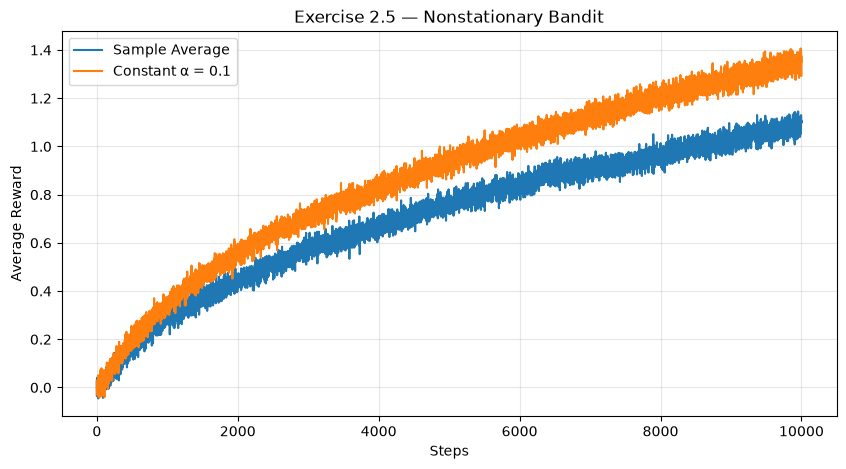

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(sample_rewards, label="Sample Average")
plt.plot(constant_rewards, label="Constant α = 0.1")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Exercise 2.5 — Nonstationary Bandit")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

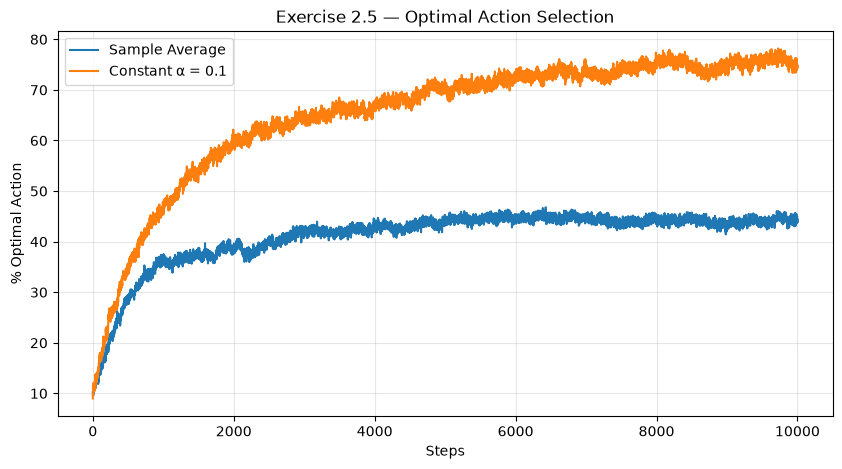

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(sample_optimal, label="Sample Average")
plt.plot(constant_optimal, label="Constant α = 0.1")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Exercise 2.5 — Optimal Action Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()